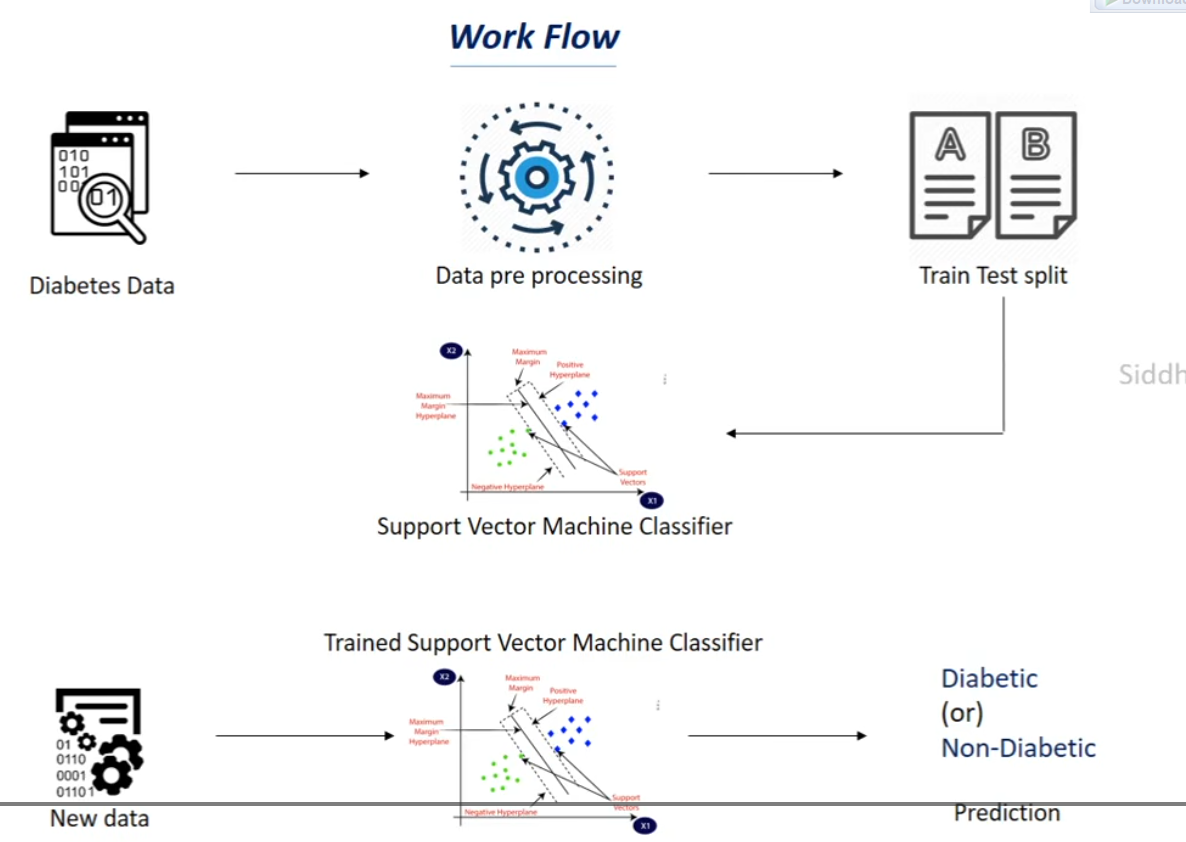


DATASET LINK "https://www.dropbox.com/scl/fi/0uiujtei423te1q4kvrny/diabetes.csv?rlkey=20xvytca6xbio4vsowi2hdj8e&e=1&dl=0"



Data Pre-processing: After obtaining the dataset, the data must be analyzed and standardized. Because the various medical attributes (like blood glucose and BMI) exist in different ranges, they need to be brought into a common range to make the data suitable for the machine learning model.

Splitting the Data: The processed data is split into training data (to train the model) and testing data (to evaluate the model's accuracy).

Model Training and Prediction: The training data is fed into a Support Vector Machine (SVM) classifier. Once trained, this classifier can be used to predict whether a new patient is diabetic or non-diabetic based on their medical information.





importing libraries

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

Data Collection and Analysis

In [6]:
diabetes_dataset = pd.read_csv("D:\PROJECTS\ML PROJECT\Diabetes prediction\diabetes.csv")
diabetes_dataset.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\MY PC\AppData\Local\Temp\ipykernel_2928\838256915.py:1: SyntaxWarning: invalid escape sequence '\P'
  diabetes_dataset = pd.read_csv("D:\PROJECTS\ML PROJECT\Diabetes prediction\diabetes.csv")


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [7]:
diabetes_dataset.shape #(768 rows, 9 columns)

(768, 9)

In [8]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
diabetes_dataset["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
diabetes_dataset.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [11]:
X = diabetes_dataset.drop(columns = "Outcome", axis=1)
Y = diabetes_dataset["Outcome"]
X.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
5,5,116,74,0,0,25.6,0.201,30
6,3,78,50,32,88,31.0,0.248,26
7,10,115,0,0,0,35.3,0.134,29
8,2,197,70,45,543,30.5,0.158,53
9,8,125,96,0,0,0.0,0.232,54


In [12]:
Y.head(5)

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

Standardize Data

In [15]:
scaler = StandardScaler()

In [16]:
scaler.fit(X)

StandardScaler()

In [17]:
standardized_data = scaler.transform(X)

In [18]:
standardized_data

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

In [19]:
X=standardized_data
X

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

train_test_split

In [21]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2, stratify=Y, random_state=2)

In [22]:
X.shape ,  X_train.shape , X_test.shape

((768, 8), (614, 8), (154, 8))

Model Training

In [24]:
classifier = svm.SVC(kernel='linear')

In [25]:
classifier.fit(X_train,Y_train)

SVC(kernel='linear')

### Model Evaluation

ACCURACY SCORE


In [67]:
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction,Y_train)
print("training_data_accuracy: ", training_data_accuracy)

training_data_accuracy:  0.7866449511400652


In [69]:
X_Test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_Test_prediction,Y_test)
print("test_data_accuracy: ", test_data_accuracy)

test_data_accuracy:  0.7727272727272727


MAKING A PREDICTIVE SYSTEM

In [87]:
input_data = (4,110,92,0,0,37.6,0.191,30)

#changing the input data to numpy array
input_data_as_array = np.asarray(input_data)

#reshape the array as w e prdicting  for one instance
input_data_reshaped = input_data_as_array .reshape(1,-1)

#standardize the input daa
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0 ):
    print("patient is Non-Diabetic")
else:
    print("patient is Diabetic")


[[ 0.04601433 -0.34096773  1.18359575 -1.28821221 -0.69289057  0.71168975
  -0.84827977 -0.27575966]]
[0]
patient is Non-Diabetic


D:\SOFTWARES\CONDA\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [91]:
input_data = (5,166,72,19,175,25.8,0.587,51)

#changing the input data to numpy array
input_data_as_array = np.asarray(input_data)

#reshape the array as w e prdicting  for one instance
input_data_reshaped = input_data_as_array .reshape(1,-1)

#standardize the input daa
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0 ):
    print("patient is Non-Diabetic")
else:
    print("patient is Diabetic")


[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
patient is Diabetic


D:\SOFTWARES\CONDA\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
